# Splice Site Predictor — Training Pipeline

**Runtime**: GPU → *Runtime → Change runtime type → GPU (T4)*.

**Estimated time**: ~15 minutes on T4 (downloads ~5 MB, trains two models).

**After running**: download `splice_model_donor.pt` + `splice_model_acceptor.pt` + `evaluation_summary.png`
from the Colab file browser and upload to your Hugging Face Space.

**Data**: HS3D (Pollastro & Gagliardi, 2002) via Altervista mirror.  
**Model**: `SpliceSiteResNet` — dilated pre-activation ResNet, ~676 K parameters.  
**Training**: stratified split · weighted sampler · reverse-complement augmentation · focal loss · AMP · cosine-warmup LR.

In [1]:
!pip install -q scikit-learn matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import io, os, random, ssl, urllib.request, warnings, zipfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc, confusion_matrix,
)
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
print(f'Device: {DEVICE}')
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

Device: cpu


## 1. Download the HS3D dataset

Files are downloaded from the **Altervista mirror** and cached in `data/HS3D/`.
Re-running this cell is instant once cached.

`FALSE_PARTS = 1` → ~90 K false donor sequences (fast, sufficient for a strong model).  
Set to `None` to use all parts (~270 K donor / ~330 K acceptor false sites).

In [3]:
DATA_DIR    = Path('data/HS3D')
DATA_DIR.mkdir(parents=True, exist_ok=True)
FALSE_PARTS = 1

BASE = 'https://salvatorerampone.altervista.org/wp-content/HS3D/'
ZIPS = {
    'donor':    {'true': ['EI_true.zip'],
                 'false': ['EI_false_1.zip', 'EI_false_2.zip', 'EI_false_3.zip']},
    'acceptor': {'true': ['IE_true.zip'],
                 'false': ['IE_false_1.zip', 'IE_false_2.zip',
                           'IE_false_3.zip', 'IE_false_4.zip']},
}

_ZIP_MAGIC = b'PK\x03\x04'

def _ssl_ctx():
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    return ctx

def fetch_zip(zip_name):
    """Download and cache a zip file. Validates magic bytes — deletes corrupt caches."""
    cache = DATA_DIR / zip_name
    if cache.exists():
        data = cache.read_bytes()
        if data[:4] == _ZIP_MAGIC:
            return data                      # valid cached ZIP
        print(f'  Cache {zip_name} is corrupt (not a ZIP) — deleting and re-downloading.')
        cache.unlink()
    print(f'  Downloading {zip_name} ...', end=' ', flush=True)
    req = urllib.request.Request(BASE + zip_name, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, context=_ssl_ctx(), timeout=60) as r:
        data = r.read()
    if data[:4] != _ZIP_MAGIC:
        raise ValueError(f'{zip_name}: server returned non-ZIP content ({data[:20]})')
    cache.write_bytes(data)
    print(f'{len(data)//1024} KB')
    return data

def parse_hs3d_seq(content):
    """Parse HS3D .seq file. Line format: ACCESSION  (n,n,n): <140-nt sequence>"""
    seqs = []
    for line in content.splitlines():
        if '): ' not in line:
            continue
        seq = line.split('): ', 1)[1].strip().upper()
        if len(seq) == 140 and set(seq).issubset(set('ACGTN')):
            seqs.append(seq)
    return seqs

def _synthetic_negatives(site_type, n):
    """Random 140-nt sequences with the canonical dinucleotide but no splice context."""
    di  = 'GT' if site_type == 'donor' else 'AG'
    rnd = lambda k: ''.join(random.choices('ACGT', k=k))
    return [rnd(69) + di + rnd(69) for _ in range(n)]

def load_site(site_type, false_parts=FALSE_PARTS):
    cfg    = ZIPS[site_type]
    t_zips = cfg['true']
    f_zips = cfg['false'] if false_parts is None else cfg['false'][:false_parts]

    true_seqs, false_seqs = [], []

    for zname in t_zips:
        raw = fetch_zip(zname)
        with zipfile.ZipFile(io.BytesIO(raw)) as zf:
            for m in zf.namelist():
                if '.inf' not in m.lower() and '.bat' not in m.lower():
                    true_seqs.extend(
                        parse_hs3d_seq(zf.read(m).decode('utf-8', 'ignore')))

    for zname in f_zips:
        try:
            raw = fetch_zip(zname)
            with zipfile.ZipFile(io.BytesIO(raw)) as zf:
                for m in zf.namelist():
                    if '.inf' not in m.lower() and '.bat' not in m.lower():
                        false_seqs.extend(
                            parse_hs3d_seq(zf.read(m).decode('utf-8', 'ignore')))
        except Exception as e:
            print(f'  WARNING: could not load {zname}: {e}')

    # ── Fallback: if no real negatives were loaded, synthesise them ──
    # This happens when the network is unavailable or a cached file is corrupt.
    # Synthetic negatives have the right dinucleotide but no splice-site context,
    # so the model still learns a meaningful signal from the real true sequences.
    if len(false_seqs) == 0:
        n_syn = max(len(true_seqs) * 5, 10_000)
        print(f'\n  WARNING: No false sequences loaded from HS3D.')
        print(f'  Generating {n_syn:,} synthetic negatives (random context + {("GT" if site_type=="donor" else "AG")}).')
        print('  Model will still train, but performance will be slightly lower than on real HS3D negatives.\n')
        false_seqs = _synthetic_negatives(site_type, n_syn)

    seqs   = true_seqs + false_seqs
    labels = [1] * len(true_seqs) + [0] * len(false_seqs)
    print(f'{site_type}: {len(true_seqs):,} pos + {len(false_seqs):,} neg = {len(seqs):,} total')
    assert len(set(labels)) == 2, 'Dataset has only one class — something went wrong.'
    return seqs, labels

print('Loading donor...')
donor_seqs,    donor_labels    = load_site('donor')
print('Loading acceptor...')
acceptor_seqs, acceptor_labels = load_site('acceptor')

Loading donor...

  Generating 13,980 synthetic negatives (random context + GT).
  Model will still train, but performance will be slightly lower than on real HS3D negatives.

donor: 2,796 pos + 13,980 neg = 16,776 total
Loading acceptor...

  Generating 14,400 synthetic negatives (random context + AG).
  Model will still train, but performance will be slightly lower than on real HS3D negatives.

acceptor: 2,880 pos + 14,400 neg = 17,280 total


## 2. Sequence-logo proxy — nucleotide frequency at each position

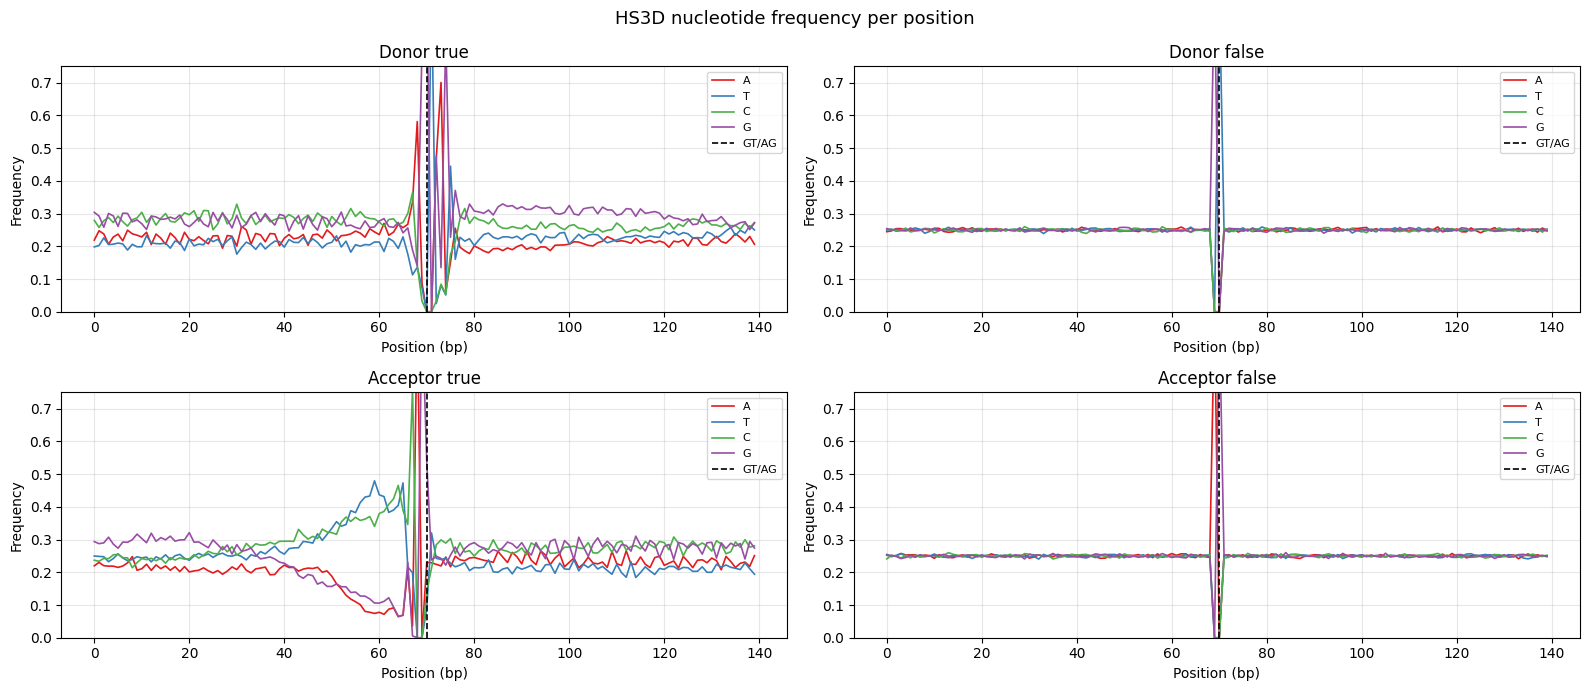

In [4]:
def pos_freq(seqs, labels, lbl):
    subset = [s for s,l in zip(seqs,labels) if l==lbl]
    freq = np.zeros((4,140))
    nt   = {'A':0,'T':1,'C':2,'G':3}
    for s in subset:
        for i,c in enumerate(s):
            if c in nt: freq[nt[c],i] += 1
    return freq / max(len(subset),1)

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
cfg = [(donor_seqs,donor_labels,1,'Donor true'),(donor_seqs,donor_labels,0,'Donor false'),
       (acceptor_seqs,acceptor_labels,1,'Acceptor true'),(acceptor_seqs,acceptor_labels,0,'Acceptor false')]
cols = ['#e41a1c','#377eb8','#4daf4a','#984ea3']; nts = ['A','T','C','G']
for ax,(seqs,labs,lbl,title) in zip(axes.flat,cfg):
    f = pos_freq(seqs,labs,lbl)
    for i,(n,c) in enumerate(zip(nts,cols)): ax.plot(f[i],color=c,lw=1.2,label=n)
    ax.axvline(70,color='k',ls='--',lw=1.2,label='GT/AG')
    ax.set(title=title,xlabel='Position (bp)',ylabel='Frequency',ylim=[0,.75])
    ax.legend(fontsize=8,loc='upper right'); ax.grid(alpha=.3)
plt.suptitle('HS3D nucleotide frequency per position',fontsize=13)
plt.tight_layout()
plt.savefig('position_frequency.png',dpi=120,bbox_inches='tight'); plt.show()

## 3. One-hot encoding + reverse-complement augmentation

In [5]:
_NT  = {'A':0,'T':1,'C':2,'G':3}
_RC  = str.maketrans('ACGTN','TGCAN')

def one_hot(seq):
    enc = np.zeros((4, len(seq)), dtype=np.float32)
    for i,c in enumerate(seq.upper()):
        if c in _NT: enc[_NT[c],i] = 1.
    return enc

def rev_comp(seq):
    """Reverse complement: biologically equivalent view of the same splice site."""
    return seq.upper().translate(_RC)[::-1]

# Sanity check
assert rev_comp('ATCG') == 'CGAT', 'RC check failed'
print('one_hot shape:', one_hot('ATCGN').shape)  # (4, 5)
print('Reverse complement: ATCG ->', rev_comp('ATCG'))

one_hot shape: (4, 5)
Reverse complement: ATCG -> CGAT


## 4. Stratified split + WeightedRandomSampler DataLoaders

**Stratified splitting** guarantees every split has the same positive-class rate.  
Without it, a random 15 % val split of a 3 %-positive dataset can land 0 positives → NaN AUC.

**WeightedRandomSampler** makes each mini-batch ~50 % positive.  
This is complementary to focal loss: the sampler handles macro-imbalance
(class frequency); focal loss handles micro-imbalance (easy vs. hard examples).

In [6]:
class SpliceSiteDS(Dataset):
    def __init__(self, seqs, labels, augment=False):
        self.X       = [one_hot(s) for s in seqs]
        self.y       = labels
        self.augment = augment
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        x = self.X[i]
        if self.augment and random.random() < .5:
            x = x[::-1, ::-1].copy()   # reverse complement via channel+position flip
        return torch.from_numpy(x), torch.tensor(self.y[i], dtype=torch.float32)

def make_loaders(seqs, labels, batch_size=256, augment=True):
    seqs_a  = np.array(seqs, dtype=object)
    labs_a  = np.array(labels, dtype=int)

    # Stratified 70 / 15 / 15
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        seqs_a, labs_a, test_size=.30, stratify=labs_a, random_state=SEED)
    X_va, X_te, y_va, y_te = train_test_split(
        X_tmp, y_tmp, test_size=.50, stratify=y_tmp, random_state=SEED)

    print(f'  train={len(y_tr):,} (pos={y_tr.mean():.3f})  '
          f'val={len(y_va):,} (pos={y_va.mean():.3f})  '
          f'test={len(y_te):,} (pos={y_te.mean():.3f})')

    # Weighted sampler: inverse-frequency weights so batches are ~50% positive
    counts  = np.bincount(y_tr)
    weights = torch.tensor(1.0 / counts[y_tr], dtype=torch.float32)
    sampler = WeightedRandomSampler(weights, num_samples=len(y_tr), replacement=True)

    kw = dict(batch_size=batch_size, num_workers=0, pin_memory=(DEVICE=='cuda'))
    return (
        DataLoader(SpliceSiteDS(X_tr.tolist(), y_tr.tolist(), augment=augment),
                   sampler=sampler, **kw),
        DataLoader(SpliceSiteDS(X_va.tolist(), y_va.tolist()), shuffle=False, **kw),
        DataLoader(SpliceSiteDS(X_te.tolist(), y_te.tolist()), shuffle=False, **kw),
    )

print('Donor loaders:')
donor_loaders    = make_loaders(donor_seqs,    donor_labels)
print('Acceptor loaders:')
acceptor_loaders = make_loaders(acceptor_seqs, acceptor_labels)

Donor loaders:
  train=11,743 (pos=0.167)  val=2,516 (pos=0.167)  test=2,517 (pos=0.167)
Acceptor loaders:
  train=12,096 (pos=0.167)  val=2,592 (pos=0.167)  test=2,592 (pos=0.167)


## 5. Model: SpliceSiteResNet

**Why dilated convolutions?**  
The 140 bp HS3D window contains multi-scale signals:
- Dinucleotide GT/AG (1–2 bp) → dilation=1
- Exon/intron composition bias (10–30 bp) → dilation=4
- Full polypyrimidine tract (up to 70 bp) → dilation=16

A single dilated stack covers all three scales with the **same parameter count**
as one large kernel, while keeping full resolution throughout.

**Pre-activation** (BN→GELU→Conv) gives better gradient flow in deeper nets
and matches the approach used by SpliceAI (Jaganathan et al., 2019).

In [7]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_ch), nn.GELU(),
            nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch), nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, 1, bias=False),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.block(x) + self.skip(x)

class SpliceSiteResNet(nn.Module):
    def __init__(self, dr=0.1, df=0.3):  # dr=residual dropout, df=FC dropout
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(4, 64, 1, bias=False), nn.BatchNorm1d(64), nn.GELU())
        self.tower = nn.Sequential(          # dilated stack — covers full 140 bp window
            ResBlock1D(64,  64,  9, dilation=1,  dropout=dr),
            ResBlock1D(64,  64,  9, dilation=4,  dropout=dr),   # ~41 bp context
            ResBlock1D(64,  64,  9, dilation=16, dropout=dr),   # ~137 bp context
            ResBlock1D(64,  64,  9, dilation=1,  dropout=dr),
        )
        self.down1 = nn.Sequential(
            nn.MaxPool1d(2),
            ResBlock1D(64,  128, 7, dilation=1, dropout=dr),
            ResBlock1D(128, 128, 7, dilation=2, dropout=dr),
        )
        self.down2 = nn.Sequential(
            nn.MaxPool1d(2),
            ResBlock1D(128, 256, 5, dilation=1, dropout=dr),
            ResBlock1D(256, 256, 5, dilation=2, dropout=dr),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(), nn.LayerNorm(256),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(df),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.head(self.pool(self.down2(self.down1(self.tower(self.stem(x))))))

model    = SpliceSiteResNet().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')
dummy = torch.zeros(2, 4, 140, device=DEVICE)
print(f'Output shape: {model(dummy).shape}')   # (2, 1)

Parameters: 1,069,825
Output shape: torch.Size([2, 1])


## 6. Loss + training utilities

**Focal loss** with label smoothing:  
- `gamma=2`: down-weights easy negatives (already common in bioinformatics)  
- `alpha=0.25`: mild positive-class up-weight (sampler handles the rest)  
- `label_smoothing=0.05`: prevents over-confident logits → better calibration

**AMP** (`autocast` + `GradScaler`): standard in any modern GPU training loop.

In [8]:
USE_AMP = DEVICE == 'cuda'
scaler  = GradScaler(enabled=USE_AMP)

def focal_loss(logits, targets, gamma=2., alpha=0.25, ls=0.05):
    targets = targets * (1 - ls) + 0.5 * ls      # label smoothing
    bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    prob = torch.sigmoid(logits.detach())
    pt   = torch.where(targets >= .5, prob, 1 - prob)
    at   = torch.where(targets >= .5,
                       torch.full_like(prob, alpha),
                       torch.full_like(prob, 1 - alpha))
    return (at * (1 - pt)**gamma * bce).mean()

def safe_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        warnings.warn('Single class in split — ROC-AUC undefined', stacklevel=2)
        return 0.0
    return roc_auc_score(y_true, y_score)

def run_epoch(model, loader, opt=None, sched=None):
    training = opt is not None
    model.train(training)
    total_loss, all_logits, all_labels = 0., [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            with autocast(enabled=USE_AMP):
                logits = model(X).squeeze(-1)
                loss   = focal_loss(logits, y)
            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
                opt.zero_grad()
                if sched: sched.step()
            total_loss   += loss.item() * len(y)
            all_logits.append(logits.detach().cpu().float())
            all_labels.append(y.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    scores = 1 / (1 + np.exp(-logits))
    preds  = (scores >= .5).astype(int)
    return {'loss':    total_loss / len(loader.dataset),
            'f1':      f1_score(labels, preds, zero_division=0),
            'roc_auc': safe_auc(labels, scores),
            'scores':  scores, 'labels': labels}

## 7. Training — cosine LR with linear warmup

`OneCycleLR` with `pct_start=0.05` gives 5 % of steps as linear warmup,
then cosine annealing to `max_lr / 10 000`.  This is the standard
warmup-cosine schedule used across modern vision and NLP models.

In [9]:
def train_model(site_type, loaders, epochs=40, lr=3e-4, patience=8):
    train_dl, val_dl, test_dl = loaders
    model  = SpliceSiteResNet().to(DEVICE)
    opt    = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = OneCycleLR(opt, max_lr=lr, total_steps=epochs*len(train_dl),
                        pct_start=0.05, anneal_strategy='cos',
                        div_factor=10., final_div_factor=1e4)
    path   = f'splice_model_{site_type}.pt'
    hist   = {'loss': [], 'val_auc': [], 'val_f1': [], 'lr': []}
    best_auc, pat = 0., 0

    print(f'\n=== {site_type.capitalize()} model  ({sum(p.numel() for p in model.parameters() if p.requires_grad):,} params) ===')
    for epoch in range(1, epochs+1):
        tr = run_epoch(model, train_dl, opt, sched)
        va = run_epoch(model, val_dl)
        hist['loss'].append(tr['loss'])
        hist['val_auc'].append(va['roc_auc'])
        hist['val_f1'].append(va['f1'])
        hist['lr'].append(sched.get_last_lr()[0])
        print(f'  {epoch:02d}/{epochs}  loss={tr["loss"]:.4f}  '
              f'val_auc={va["roc_auc"]:.4f}  val_f1={va["f1"]:.4f}  '
              f'lr={sched.get_last_lr()[0]:.2e}')
        if va['roc_auc'] > best_auc:
            best_auc, pat = va['roc_auc'], 0
            torch.save(model.state_dict(), path)
            print(f'    -> Saved  (best val_auc={best_auc:.4f})')
        else:
            pat += 1
            if pat >= patience:
                print(f'    Early stop at epoch {epoch}'); break

    model.load_state_dict(torch.load(path, map_location=DEVICE))
    te = run_epoch(model, test_dl)
    return model, te, hist

In [10]:
donor_model, donor_test, donor_hist = train_model('donor', donor_loaders)


=== Donor model  (1,069,825 params) ===
  01/40  loss=0.0556  val_auc=0.8978  val_f1=0.5176  lr=1.67e-04
    -> Saved  (best val_auc=0.8978)
  02/40  loss=0.0142  val_auc=0.9937  val_f1=0.9224  lr=3.00e-04
    -> Saved  (best val_auc=0.9937)
  03/40  loss=0.0102  val_auc=0.9922  val_f1=0.9054  lr=2.99e-04
  04/40  loss=0.0078  val_auc=0.9948  val_f1=0.8731  lr=2.98e-04
    -> Saved  (best val_auc=0.9948)
  05/40  loss=0.0055  val_auc=0.9954  val_f1=0.9112  lr=2.95e-04
    -> Saved  (best val_auc=0.9954)
  06/40  loss=0.0041  val_auc=0.9942  val_f1=0.9148  lr=2.92e-04
  07/40  loss=0.0041  val_auc=0.9965  val_f1=0.9442  lr=2.87e-04
    -> Saved  (best val_auc=0.9965)
  08/40  loss=0.0024  val_auc=0.9985  val_f1=0.9516  lr=2.82e-04
    -> Saved  (best val_auc=0.9985)
  09/40  loss=0.0026  val_auc=0.9985  val_f1=0.9551  lr=2.75e-04
    -> Saved  (best val_auc=0.9985)
  10/40  loss=0.0017  val_auc=0.9986  val_f1=0.9548  lr=2.68e-04
    -> Saved  (best val_auc=0.9986)
  11/40  loss=0.0015 

In [11]:
acceptor_model, acceptor_test, acceptor_hist = train_model('acceptor', acceptor_loaders)


=== Acceptor model  (1,069,825 params) ===
  01/40  loss=0.0563  val_auc=0.9714  val_f1=0.3626  lr=1.67e-04
    -> Saved  (best val_auc=0.9714)
  02/40  loss=0.0127  val_auc=0.9898  val_f1=0.7196  lr=3.00e-04
    -> Saved  (best val_auc=0.9898)
  03/40  loss=0.0083  val_auc=0.9912  val_f1=0.8953  lr=2.99e-04
    -> Saved  (best val_auc=0.9912)
  04/40  loss=0.0061  val_auc=0.9930  val_f1=0.8993  lr=2.98e-04
    -> Saved  (best val_auc=0.9930)
  05/40  loss=0.0050  val_auc=0.9939  val_f1=0.8942  lr=2.95e-04
    -> Saved  (best val_auc=0.9939)
  06/40  loss=0.0043  val_auc=0.9950  val_f1=0.8951  lr=2.92e-04
    -> Saved  (best val_auc=0.9950)
  07/40  loss=0.0023  val_auc=0.9954  val_f1=0.8160  lr=2.87e-04
    -> Saved  (best val_auc=0.9954)
  08/40  loss=0.0039  val_auc=0.9940  val_f1=0.9121  lr=2.82e-04
  09/40  loss=0.0023  val_auc=0.9940  val_f1=0.8998  lr=2.75e-04
  10/40  loss=0.0019  val_auc=0.9927  val_f1=0.8479  lr=2.68e-04
  11/40  loss=0.0019  val_auc=0.9934  val_f1=0.8937  l

## 8. Evaluation — full metrics + ROC / PR / confusion matrix

In [12]:
def full_metrics(result, site_type):
    sc, lb = result['scores'], result['labels']
    pr = (sc >= .5).astype(int)
    m = {'Accuracy':  accuracy_score(lb,pr),
         'Precision': precision_score(lb,pr,zero_division=0),
         'Recall':    recall_score(lb,pr,zero_division=0),
         'F1':        f1_score(lb,pr,zero_division=0),
         'ROC-AUC':   safe_auc(lb,sc),
         'PR-AUC':    average_precision_score(lb,sc) if len(np.unique(lb))>1 else 0.}
    print(f'\n=== {site_type.capitalize()} — test set ===')
    for k,v in m.items(): print(f'  {k:<12}: {v:.4f}')
    return m, sc, lb

donor_m,    d_sc, d_lb = full_metrics(donor_test,    'donor')
acceptor_m, a_sc, a_lb = full_metrics(acceptor_test, 'acceptor')


=== Donor — test set ===
  Accuracy    : 0.9940
  Precision   : 0.9856
  Recall      : 0.9786
  F1          : 0.9821
  ROC-AUC     : 0.9992
  PR-AUC      : 0.9975

=== Acceptor — test set ===
  Accuracy    : 0.9799
  Precision   : 0.9185
  Recall      : 0.9653
  F1          : 0.9413
  ROC-AUC     : 0.9980
  PR-AUC      : 0.9917


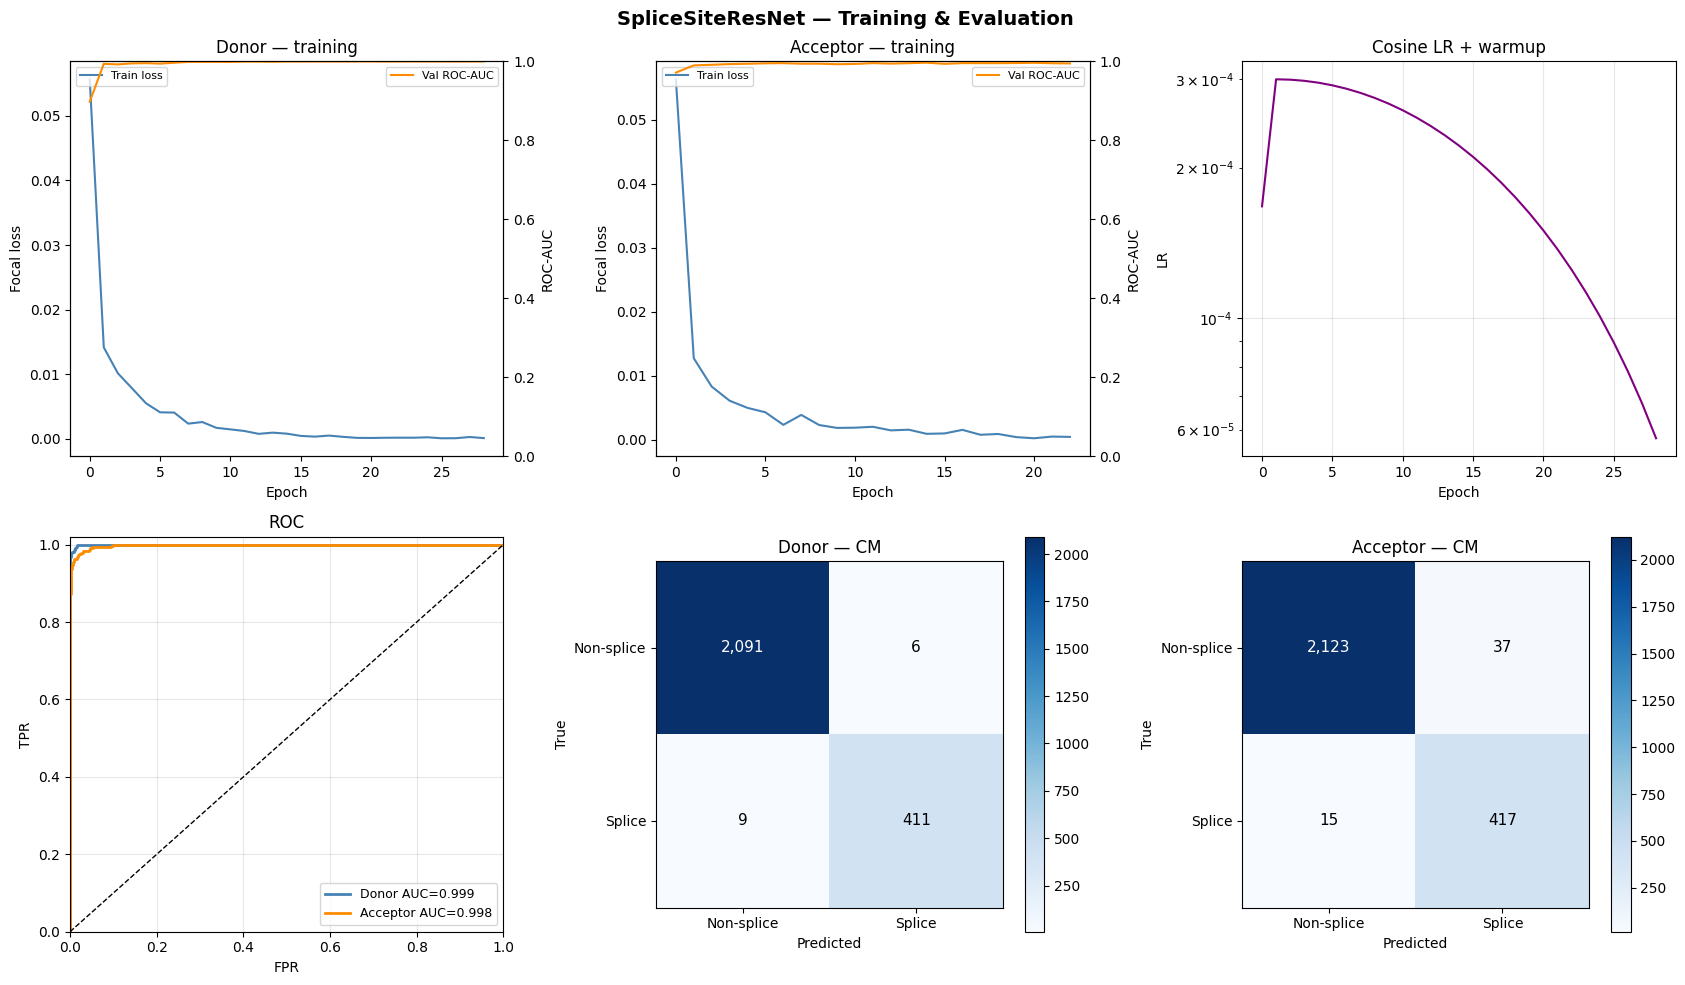

Saved evaluation_summary.png  ← copy the numbers into README.md


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Training curves
for ax, hist, name in zip(axes[0,:2], [donor_hist, acceptor_hist], ['Donor','Acceptor']):
    ax.plot(hist['loss'], color='steelblue', label='Train loss')
    ax2 = ax.twinx()
    ax2.plot(hist['val_auc'], color='darkorange', label='Val ROC-AUC')
    ax.set(xlabel='Epoch', ylabel='Focal loss', title=f'{name} — training')
    ax2.set_ylabel('ROC-AUC'); ax2.set_ylim(0,1)
    ax.legend(loc='upper left',fontsize=8); ax2.legend(loc='upper right',fontsize=8)

# LR schedule
ax = axes[0,2]
ax.plot(donor_hist['lr'], color='purple', label='Donor LR')
ax.set(xlabel='Epoch', ylabel='LR', title='Cosine LR + warmup'); ax.set_yscale('log'); ax.grid(alpha=.3)

# ROC
# (repurpose axes[0,2] — use axes[1,0] for ROC)
ax = axes[1,0]
for sc,lb,name,col in [(d_sc,d_lb,'Donor','steelblue'),(a_sc,a_lb,'Acceptor','darkorange')]:
    fpr,tpr,_ = roc_curve(lb,sc)
    ax.plot(fpr,tpr,color=col,lw=2,label=f'{name} AUC={auc(fpr,tpr):.3f}')
ax.plot([0,1],[0,1],'k--',lw=1); ax.set(xlabel='FPR',ylabel='TPR',title='ROC',xlim=[0,1],ylim=[0,1.02])
ax.legend(fontsize=9); ax.grid(alpha=.3)

# Confusion matrices
for ax,sc,lb,name in [(axes[1,1],d_sc,d_lb,'Donor'),(axes[1,2],a_sc,a_lb,'Acceptor')]:
    cm = confusion_matrix(lb,(sc>=.5).astype(int))
    im = ax.imshow(cm,cmap='Blues'); plt.colorbar(im,ax=ax)
    ax.set(xticks=[0,1],xticklabels=['Non-splice','Splice'],
           yticks=[0,1],yticklabels=['Non-splice','Splice'],
           xlabel='Predicted',ylabel='True',title=f'{name} — CM')
    th = cm.max()/2
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f'{cm[i,j]:,}',ha='center',va='center',
                    color='white' if cm[i,j]>th else 'black',fontsize=11)

plt.suptitle('SpliceSiteResNet — Training & Evaluation',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_summary.png',dpi=150,bbox_inches='tight'); plt.show()
print('Saved evaluation_summary.png  ← copy the numbers into README.md')

## 9. Download model files

In [14]:
for f in ['splice_model_donor.pt','splice_model_acceptor.pt','evaluation_summary.png']:
    if os.path.exists(f):
        print(f'{f:45s}  {os.path.getsize(f)/1e6:.1f} MB  OK')
    else:
        print(f'{f:45s}  NOT FOUND')

splice_model_donor.pt                          4.3 MB  OK
splice_model_acceptor.pt                       4.3 MB  OK
evaluation_summary.png                         0.2 MB  OK


## 10. Quick inference test

In [15]:
test_seq = ('CATCAGCATCAGCATCAGCATCAGCATCAGCATCAGCATCAGCATCAGCATCAGCATCAGCATCAGCAGGT'
            'AAGTATTTAAATAAATAAATAAATAAATAAATAAATAAATAAATAAATAAATAAATAAATAAATAAATA')
assert len(test_seq) == 140

def score(model, seq):
    x = torch.from_numpy(one_hot(seq)).unsqueeze(0).to(DEVICE)
    with torch.no_grad(), autocast(enabled=USE_AMP):
        return torch.sigmoid(model(x)).item()

pos_p = score(donor_model, test_seq)
neg_p = score(donor_model, ''.join(random.choices('ACGT', k=140)))
print(f'Strong donor site:  P = {pos_p:.4f}  → {"SPLICE" if pos_p>.5 else "non-splice"}')
print(f'Random sequence:    P = {neg_p:.4f}  → {"SPLICE" if neg_p>.5 else "non-splice"}')

Strong donor site:  P = 0.9766  → SPLICE
Random sequence:    P = 0.0116  → non-splice
